In [ ]:
import pandas as pd
# this library is needed when there's string that looks like dictionary or ls
import ast

members  = "initial-dataset/team_members_without_cold.csv"

members_df  = pd.read_csv(members,  engine="python", on_bad_lines="skip")

print("Members Dataset :", members_df.shape)

print(members_df.columns)

Members Dataset : (66553, 3)
Index(['project_id', 'member_id', 'member_description'], dtype='str')


In [2]:
members_df.head()

,project_id,member_id,member_description
0,0,15539,I worked on the Backend with flask and linking...
1,0,4474,NaN
2,0,7650,I was responsible for my teams artistic ventur...
3,0,4951,I built the frontend using React and set up th...
4,1,16897,NaN


## New Graph: Bipartite Graph (User-project_:slug) 👫👩🏾‍🤝‍👩🏼

In [3]:
import networkx as nx

# 1) membership table: unique (uid, project_slug)
membership = members_df[["member_id", "project_id"]].drop_duplicates().copy()

# 2) build empty bipartite graph first
# If directed: nx.DiGraph()
B = nx.Graph()

# add developer nodes
# Loop over users and get them unique in the form of u: member_id
dev_nodes = [f"User:{int(u)}" for u in membership["member_id"].unique()]

# Add all nodes and make them of type developer
B.add_nodes_from(dev_nodes, bipartite="developer")

# add task/project nodes (Same explaination as dev_nodes)
task_nodes = [f"Project:{s}" for s in membership["project_id"].unique()]
B.add_nodes_from(task_nodes, bipartite="task")

# add edges: developer <-> task
# Loop over all membershio records and build edge between them (pairs)
edge_list = [(f"User:{int(u)}", f"Project:{s}") for u, s in membership.itertuples(index=False)]
# Put edges inside the graph
B.add_edges_from(edge_list)

print("Bipartite Graph nodes:", B.number_of_nodes())
print("Bipartite Graph edges:", B.number_of_edges())

Bipartite Graph nodes: 57031
Bipartite Graph edges: 66553


In [4]:
print(membership.head())

   member_id  project_id
0      15539           0
1       4474           0
2       7650           0
3       4951           0
4      16897           1


In [5]:
# In the form of pairs
list(B.edges())[:5]

[('User:15539', 'Project:0'),
 ('User:15539', 'Project:587'),
 ('User:4474', 'Project:0'),
 ('User:7650', 'Project:0'),
 ('User:4951', 'Project:0')]

In [6]:
from networkx.algorithms import bipartite

print("Is bipartite?", bipartite.is_bipartite(B))

Is bipartite? True


In [7]:
# Checl if there are edges between users or projects (Bad Edges)
bad_edges = []

for a, b in B.edges():
    if a[0] == b[0]:   # both start with 'u:' or both 'p:'
        bad_edges.append((a, b))

print("Bad edges count:", len(bad_edges))
print("Sample bad edges:", bad_edges[:5])

Bad edges count: 0
Sample bad edges: []


In [8]:
print("Membership rows:", len(membership))
print("Graph edges:", B.number_of_edges())

Membership rows: 66553
Graph edges: 66553


In [9]:
missing_users = [
    f"User:{int(u)}"
    for u in members_df["member_id"].unique()
    if f"User:{int(u)}" not in B
]

print("Missing users:", len(missing_users))

Missing users: 0


In [10]:
missing_tasks = [
    f"Project:{s}"
    for s in members_df["project_id"].unique()
    if f"Project:{s}" not in B
]

print("Missing tasks:", len(missing_tasks))

Missing tasks: 0


In [11]:
isolated = list(nx.isolates(B))
print("Isolated nodes:", len(isolated))
print("Sample:", isolated[:10])

Isolated nodes: 0
Sample: []


Subgraph nodes: 15
Subgraph edges: 12


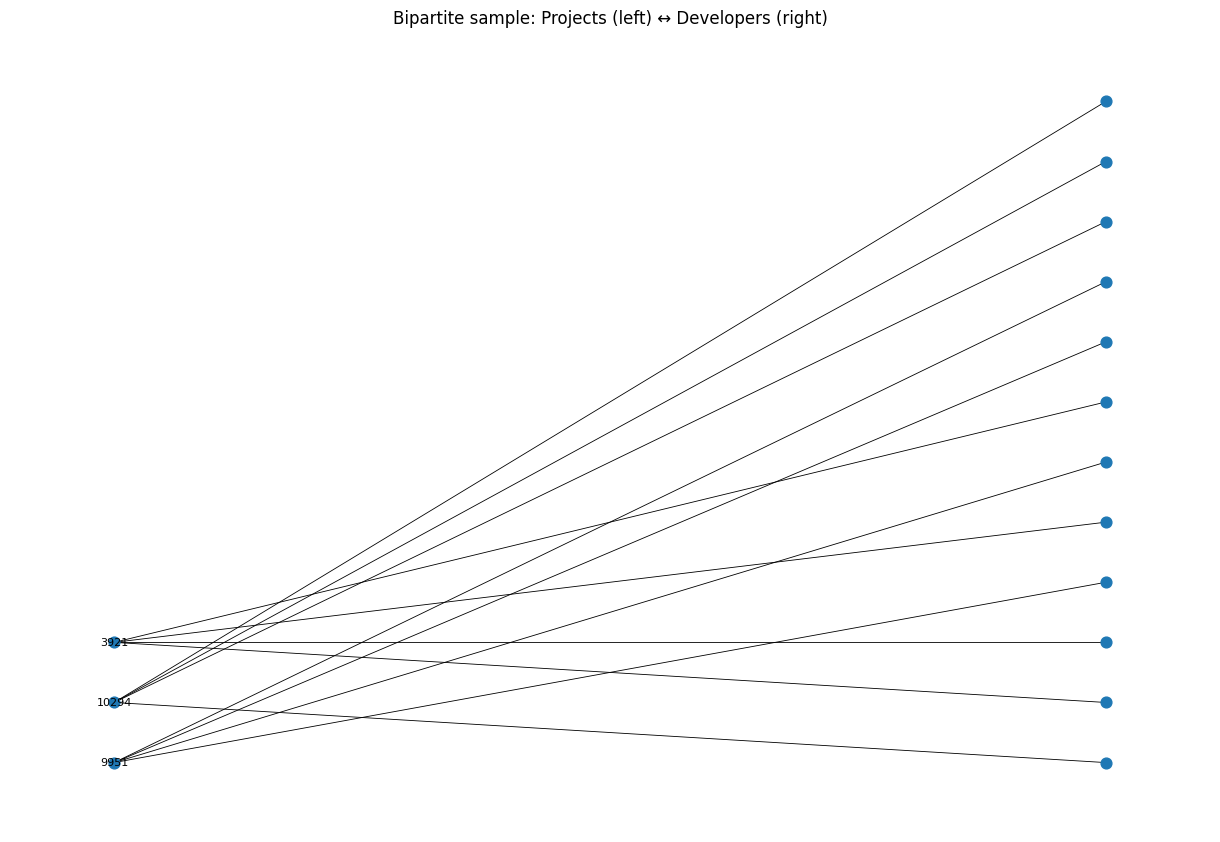

In [12]:
import random
import networkx as nx
import matplotlib.pyplot as plt

k_tasks = min(3, len(task_nodes))

task_nodes = [n for n in B.nodes() if str(n).startswith("Project:")]
dev_nodes  = [n for n in B.nodes() if str(n).startswith("User:")]

sample_tasks = random.sample(task_nodes, k_tasks)

sub_nodes = set(sample_tasks)
for t in sample_tasks:
    sub_nodes.update(B.neighbors(t))

H = B.subgraph(sub_nodes).copy()

print("Subgraph nodes:", H.number_of_nodes())
print("Subgraph edges:", H.number_of_edges())

left  = [n for n in H.nodes() if str(n).startswith("Project:")]
right = [n for n in H.nodes() if str(n).startswith("User:")]

pos = {}
pos.update({n: (0, i) for i, n in enumerate(left)})   # tasks left
pos.update({n: (1, i) for i, n in enumerate(right)})  # devs right

plt.figure(figsize=(12, 8))
nx.draw(H, pos, with_labels=False, node_size=60, width=0.6)

nx.draw_networkx_labels(
    H, pos,
    labels={n: n.replace("Project:", "")[:18] for n in left},
    font_size=8
)

plt.title("Bipartite sample: Projects (left) ↔ Developers (right)")
plt.axis("off")
plt.show()

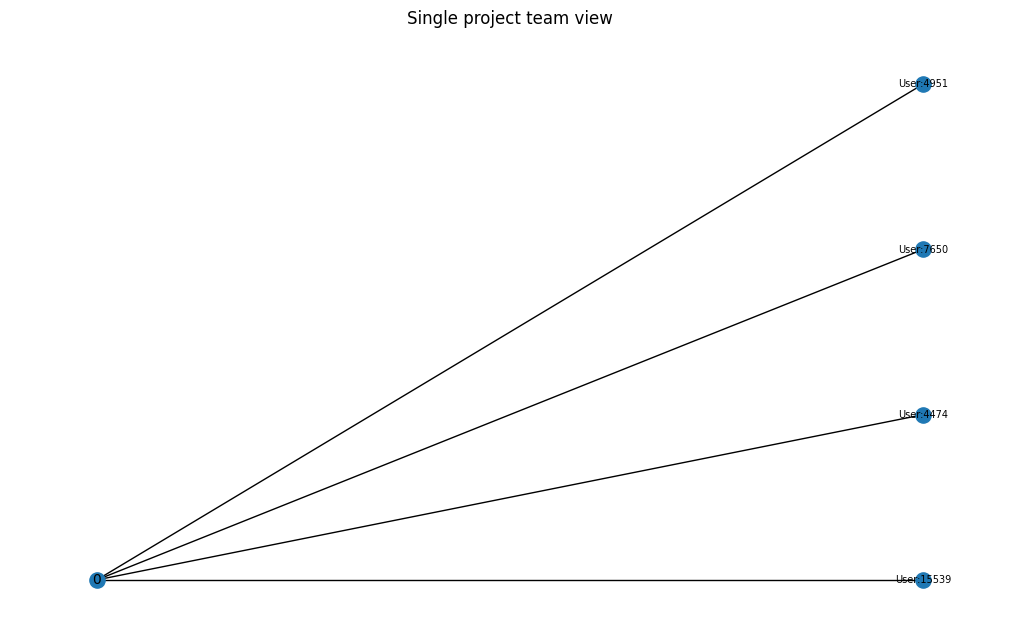

In [13]:
import matplotlib.pyplot as plt
import networkx as nx

t = [n for n in B.nodes() if str(n).startswith("Project:")][0]
team = list(B.neighbors(t))

H = B.subgraph([t] + team).copy()

pos = {t: (0, 0)}
for i, u in enumerate(team):
    pos[u] = (1, i)

plt.figure(figsize=(10, 6))
nx.draw(H, pos, with_labels=False, node_size=120, width=1)

nx.draw_networkx_labels(H, pos, labels={t: t.replace("Project:", "")[:30]}, font_size=10)
nx.draw_networkx_labels(
    H, pos,
    labels={u: u for u in team[:15]},
    font_size=7
)

plt.title("Single project team view")
plt.axis("off")
plt.show()

In [14]:
# # edges_bip = sorted(B.edges())

# pd.DataFrame(edges_bip, columns=["User", "Project"]).to_csv(
#     "graph_data/B_graph.csv",
#     index=False
# )

# print("Saved bipartite graph to file ✅")

In [15]:
edges_df = membership[["member_id", "project_id"]].drop_duplicates().copy()

edges_df["member_id"] = edges_df["member_id"].astype(int)
edges_df["project_id"] = edges_df["project_id"].astype(int)

edges_df.to_csv("graph_data/B_graph.csv", index=False)
print(edges_df.head())
print("Edges:", len(edges_df))

   member_id  project_id
0      15539           0
1       4474           0
2       7650           0
3       4951           0
4      16897           1
Edges: 66553


In [16]:
print("Self-loops before:", len(list(nx.selfloop_edges(B))))
B.remove_edges_from(nx.selfloop_edges(B))
print("Self-loops after:", len(list(nx.selfloop_edges(B))))

Self-loops before: 0
Self-loops after: 0
